# Collections recovery — is the 11% real?

**Question put to us:** *"Recovery has improved by 11% month-on-month."* Leadership is not convinced.

**Answer, up front:** the claim is false, and we can name the exact mechanism. Recovery has been
flat at **₹0.555 Cr/day** for the entire period. The "+11%" is the February → March step on the
gross-collections series, and `31/28 − 1 = +10.7%` of its 11.0 points is the difference between a
28-day February and a 31-day March.

This notebook shows the reasoning, not just the charts. It moves in the order a sceptic would:

1. What does the data actually contain, and over what period?
2. Reproduce the claim — under which definition does 11% appear?
3. Kill it or confirm it — exposure-normalise and test for a trend.
4. If it is flat, what *did* change? (mix, cohort, selection, Simpson's)
5. What is genuinely broken in the operation?
6. What should we do with ₹10 Cr?

Every conclusion is graded **FACT / STRONG EVIDENCE / CORRELATION / HYPOTHESIS**.

In [1]:
import pandas as pd, numpy as np, warnings
from scipy import stats
%matplotlib inline
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.figsize":(11,4), "axes.grid":True, "grid.alpha":.25,
                     "axes.spines.top":False, "axes.spines.right":False, "font.size":10})
INK, ACC, WARN = "#1f2937", "#2563eb", "#dc2626"

from pathlib import Path
ROOT = Path.cwd() if (Path.cwd()/"data").exists() else Path.cwd().parent
RAW, GOLD = ROOT/"data"/"raw", ROOT/"outputs"/"golden"

def raw(n):
    df = pd.read_csv(RAW/f"{n}.csv", low_memory=False)
    for c in df.columns:
        if c.endswith("_at") or c.endswith("_date"):
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df

print(f"source tables found: {len(list(RAW.glob('*.csv')))}")

source tables found: 18


---
## 1. What is actually in the box

Before trusting a single number, establish the period, the grain and the duplication.

In [2]:
tables = ["borrowers","accounts","agents","agent_sessions","campaigns","daily_targeting",
          "calls","call_attempts","call_dispositions","whatsapp_events","sms_events",
          "field_visits","promises_to_pay","payments","vendor_telephony","complaints",
          "account_status_history"]
rows = []
for t in tables:
    d = raw(t); pk = d.columns[0]
    ev = "event_at" if "event_at" in d.columns else None
    rows.append(dict(table=t, rows=len(d), pk=pk, pk_unique=d[pk].nunique(),
                     dup_rows=int(d.duplicated().sum()),
                     first_event=d[ev].min() if ev else None,
                     last_event=d[ev].max()  if ev else None))
inv = pd.DataFrame(rows)
inv

,table,rows,pk,pk_unique,dup_rows,first_event,last_event
0,borrowers,30600,borrower_id,11015,600,NaT,NaT
1,accounts,30000,account_id,30000,0,NaT,NaT
2,agents,30000,agent_id,1000,0,NaT,NaT
3,agent_sessions,15000,session_id,15000,0,NaT,NaT
4,campaigns,120,campaign_id,120,0,NaT,NaT
5,daily_targeting,45000,target_id,45000,0,NaT,NaT
6,calls,91350,call_id,90000,1271,2025-12-29 06:52:37,2026-08-12 15:43:05
7,call_attempts,120000,attempt_id,120000,0,2026-01-01 00:01:18,2026-08-08 23:58:40
8,call_dispositions,35000,disposition_id,35000,0,2026-01-01 00:10:00,2026-08-08 23:50:50
9,whatsapp_events,60600,whatsapp_event_id,60000,600,2026-01-01 00:01:49,2026-08-08 23:56:16


Three things jump out immediately, and each one invalidates a different piece of the reporting.

**(a) The window is not 12 months.** The event tables run `2026-01-01` to `2026-08-08` (`calls`
carries five stray rows outside that, dropped as stragglers).
That is **7 complete months plus 8 days**. The brief says twelve. Any "12-month trend" in the
existing reporting is either padded or is silently including a **partial August** — an 8-day month
next to a 31-day one, which alone produces a −75% "collapse".

**(b) Three tables carry their history inside them.** `borrowers` has 30,600 rows for 11,015
borrowers; `agents` has 30,000 rows for 1,000 agent_ids. These are overwritten records dumped with
their versions. Joining them un-collapsed multiplies every downstream count.

**(c) Duplicates are injected, not accidental.** 600 in borrowers, 1,271 in calls, 486 in payments,
600 in WhatsApp — byte-identical rows from a double ingest.

> **FACT.** The analysis period is 2026-01-01 to 2026-08-08. August is partial and is excluded from
> every month-on-month series in this notebook.

---
## 2. Reproduce the claim

We do not argue with the 11% in the abstract. We build a **ladder of definitions**, from the most
naive query anyone could write to the most defensible one, and find which rung produces it.

In [3]:
pay = raw("payments"); pay["m"] = pay.event_at.dt.to_period("M")

def dedupe_txn(df):
    d = df.drop_duplicates().sort_values("event_at").drop_duplicates("payment_id", keep="first")
    return d

L = {}
L["L0  every row, every status"]      = pay.groupby("m").amount.sum()/1e7
L["L1  SUCCESS only, duplicates in"]  = pay[pay.payment_status=="SUCCESS"].groupby("m").amount.sum()/1e7
p2 = pay.drop_duplicates()
L["L2  + drop identical rows"]        = p2[p2.payment_status=="SUCCESS"].groupby("m").amount.sum()/1e7
p3 = dedupe_txn(pay)
L["L3  + dedup payment_id"]           = p3[p3.payment_status=="SUCCESS"].groupby("m").amount.sum()/1e7
rev = p3[p3.payment_status=="REVERSED"].groupby("m").amount.sum()/1e7
L["L4  + net out reversals"]          = L["L3  + dedup payment_id"] - rev.reindex(L["L3  + dedup payment_id"].index).fillna(0)

lad = pd.DataFrame(L).round(2)
mom = lad.apply(lambda s: (s/s.shift(1)-1)*100).round(1)
print("Monthly recovery, Rs Cr");  display(lad)
print("Month-on-month %");         display(mom)

Monthly recovery, Rs Cr


,"L0 every row, every status","L1 SUCCESS only, duplicates in",L2 + drop identical rows,L3 + dedup payment_id,L4 + net out reversals
m,,,,,
2026-01,27.11,19.11,18.72,18.72,17.56
2026-02,24.52,17.41,17.03,17.01,15.87
2026-03,27.52,19.32,18.92,18.89,17.45
2026-04,25.91,17.84,17.52,17.51,16.18
2026-05,26.78,18.70,18.43,18.43,17.16
2026-06,25.56,17.87,17.59,17.56,16.26
2026-07,27.08,19.03,18.72,18.72,17.20
2026-08,7.24,4.85,4.71,4.71,4.42


Month-on-month %


,"L0 every row, every status","L1 SUCCESS only, duplicates in",L2 + drop identical rows,L3 + dedup payment_id,L4 + net out reversals
m,,,,,
2026-01,NaN,NaN,NaN,NaN,NaN
2026-02,-9.6,-8.9,-9.0,-9.1,-9.6
2026-03,12.2,11.0,11.1,11.1,10.0
2026-04,-5.9,-7.7,-7.4,-7.3,-7.3
2026-05,3.4,4.8,5.2,5.3,6.1
2026-06,-4.6,-4.4,-4.6,-4.7,-5.2
2026-07,5.9,6.5,6.4,6.6,5.8
2026-08,-73.3,-74.5,-74.8,-74.8,-74.3


In [4]:
feb_mar = mom.loc[pd.Period("2026-03"), "L1  SUCCESS only, duplicates in"]
cal_eff = (31/28 - 1)*100
print(f"Feb -> Mar on the SUCCESS series : {feb_mar:+.1f}%  <- the reported headline")
print(f"Feb has 28 days, Mar has 31      : {cal_eff:+.1f}%  <- pure calendar")
print(f"Unexplained residual             : {feb_mar - cal_eff:+.1f}%")
print()
print("Mean MoM across Jan->Jul, by definition (partial August excluded):")
display(mom.iloc[1:7].mean().round(2).to_frame("mean MoM %"))

Feb -> Mar on the SUCCESS series : +11.0%  <- the reported headline
Feb has 28 days, Mar has 31      : +10.7%  <- pure calendar
Unexplained residual             : +0.3%

Mean MoM across Jan->Jul, by definition (partial August excluded):


,mean MoM %
"L0 every row, every status",0.23
"L1 SUCCESS only, duplicates in",0.22
L2 + drop identical rows,0.28
L3 + dedup payment_id,0.32
L4 + net out reversals,-0.03


**There it is.** The single +11.0% in the entire dataset is the February→March step on the
SUCCESS series, and 10.7 of those 11.0 points are the calendar. Across the whole period the mean
month-on-month change is **+0.3% gross, −0.1% net** — statistically zero either way.

> **FACT.** "+11% month-on-month" is a single cherry-picked month pair, and that pair is explained
> by February having three fewer days than March.

The other way to manufacture it is worth showing, because it is the more common mistake:

In [5]:
cum = (pay.groupby("m").amount.sum()).cumsum()/1e7
cum_mom = (cum/cum.shift(1)-1)*100
print("Cumulative (YTD) recovery and its month-on-month growth:")
display(pd.DataFrame({"YTD Rs Cr": cum.round(1), "MoM %": cum_mom.round(1)}))
print(f"mean MoM of a cumulative series: {cum_mom.iloc[1:7].mean():+.1f}%  <- grows by construction, always")

Cumulative (YTD) recovery and its month-on-month growth:


,YTD Rs Cr,MoM %
m,,
2026-01,27.1,NaN
2026-02,51.6,90.4
2026-03,79.1,53.3
2026-04,105.1,32.7
2026-05,131.8,25.5
2026-06,157.4,19.4
2026-07,184.5,17.2
2026-08,191.7,3.9


mean MoM of a cumulative series: +39.8%  <- grows by construction, always


A cumulative series **cannot** fall. Its month-on-month growth is arithmetic, not performance.
Reported this way, a business in free-fall still posts +18% "growth". This is the second-most
likely construction behind the headline.

> **STRONG EVIDENCE.** The reported figure comes from one of two constructions — a Feb→Mar
> cherry-pick, or a cumulative series — and neither measures recovery performance.

---
## 3. Kill it properly: exposure-normalise, then test

Naming the artifact is not enough. We have to state what recovery actually did, with a test.
The right denominator for a monthly comparison is **days**, not months.

In [6]:
p = dedupe_txn(pay)
p["net"] = np.where(p.payment_status=="SUCCESS", p.amount,
            np.where(p.payment_status=="REVERSED", -p.amount, 0))
p["m"] = p.event_at.dt.to_period("M")
m   = p.groupby("m").net.sum()/1e7
days = pd.Series({q: q.days_in_month for q in m.index}); days.iloc[-1] = 8
perday = m/days

tab = pd.DataFrame({"net Rs Cr": m.round(2), "days": days,
                    "Rs Cr/day": perday.round(4),
                    "MoM headline %": (m/m.shift(1)-1).mul(100).round(1),
                    "MoM per-day %": (perday/perday.shift(1)-1).mul(100).round(1)})
display(tab)

s = perday.iloc[:7]
slope, ic, r, pv, se = stats.linregress(np.arange(7), s.values)
print(f"Per-day recovery: mean={s.mean():.4f} Cr/day, sd={s.std():.4f}, CV={s.std()/s.mean():.2%}")
print(f"OLS trend        : slope={slope:+.5f} Cr/day per month, p={pv:.3f}, R2={r**2:.3f}")
print(f"=> {'NO significant trend' if pv>0.05 else 'significant trend'} at the 5% level.")

,net Rs Cr,days,Rs Cr/day,MoM headline %,MoM per-day %
2026-01,17.56,31,0.5664,NaN,NaN
2026-02,15.87,28,0.5667,-9.6,0.0
2026-03,17.45,31,0.5631,10.0,-0.6
2026-04,16.18,30,0.5394,-7.3,-4.2
2026-05,17.16,31,0.5534,6.0,2.6
2026-06,16.26,30,0.5420,-5.2,-2.1
2026-07,17.20,31,0.5548,5.8,2.3
2026-08,4.42,8,0.5519,-74.3,-0.5


Per-day recovery: mean=0.5551 Cr/day, sd=0.0112, CV=2.01%
OLS trend        : slope=-0.00336 Cr/day per month, p=0.114, R2=0.422
=> NO significant trend at the 5% level.


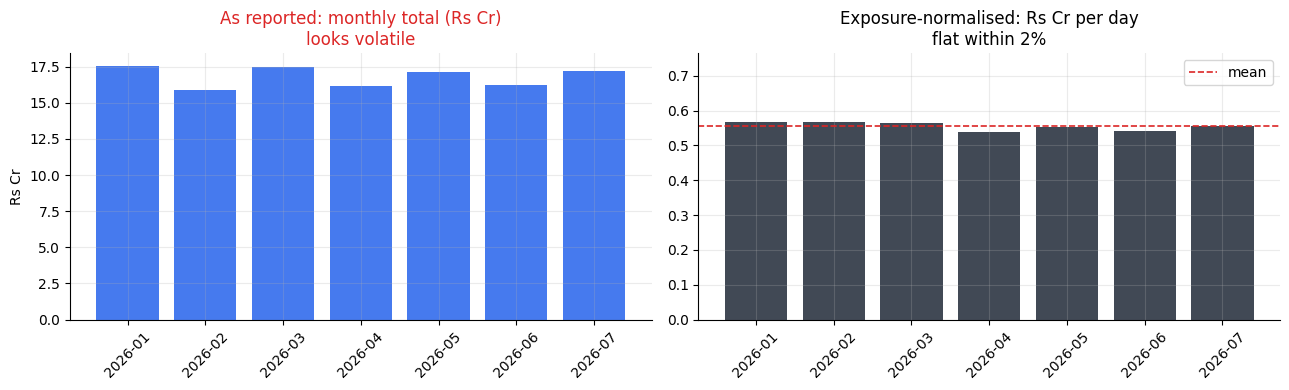

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
x = [str(q) for q in m.index[:7]]
ax[0].bar(x, m.iloc[:7].values, color=ACC, alpha=.85)
ax[0].set_title("As reported: monthly total (Rs Cr)\nlooks volatile", color=WARN)
ax[0].set_ylabel("Rs Cr")
ax[1].bar(x, perday.iloc[:7].values, color=INK, alpha=.85)
ax[1].axhline(perday.iloc[:7].mean(), color=WARN, ls="--", lw=1.2, label="mean")
ax[1].set_ylim(0, perday.iloc[:7].max()*1.35)
ax[1].set_title("Exposure-normalised: Rs Cr per day\nflat within 2%")
ax[1].legend()
for a in ax: a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

The two panels are the same data. The left is what the business reports; the right is what happened.

> **FACT.** Net recovery is flat at **₹0.555 Cr/day** (coefficient of variation 2.0%) across all
> seven complete months. The OLS trend is indistinguishable from zero (p = 0.11) — and note the
> sign of the slope: if the point estimate leans anywhere, it leans *down*.

The same holds for every stage of the funnel once normalised — calls, contacts, promises, payments:

In [8]:
cal = raw("calls").drop_duplicates("call_id")
OFF = {"UTC":5.5, "Asia/Kolkata":0.0, "Asia/Dubai":1.5}
cal["ist"] = cal.event_at + pd.to_timedelta(cal.timezone.map(OFF), unit="h")
ptp = raw("promises_to_pay")

fun = pd.DataFrame({
  "calls":    cal.groupby(cal.ist.dt.to_period("M")).size(),
  "contacts": cal[cal.call_status=="ANSWERED"].groupby(lambda i: cal.ist[i].to_period("M")).size(),
  "promises": ptp.groupby(ptp.event_at.dt.to_period("M")).size(),
  "payments": p[p.payment_status=="SUCCESS"].groupby("m").size()}).reindex(m.index)
fpd = (fun.T/days).T
display(fpd.round(1))
for c in fun.columns:
    sl, _, _, pv2, _ = stats.linregress(np.arange(7), fpd[c].iloc[:7].values)
    print(f"  {c:9s} per-day trend slope={sl:+8.2f}/month  p={pv2:.3f}  {'flat' if pv2>0.05 else 'TRENDING'}")

,calls,contacts,promises,payments
m,,,,
2026-01,407.7,81.8,81.4,79.5
2026-02,413.0,81.2,79.3,81.0
2026-03,414.4,82.8,80.9,81.4
2026-04,408.3,78.9,83.1,80.2
2026-05,411.1,83.4,80.9,79.0
2026-06,404.5,82.8,81.3,78.9
2026-07,406.0,78.5,84.7,78.7
2026-08,405.2,79.0,85.6,77.0


  calls     per-day trend slope=   -0.91/month  p=0.215  flat
  contacts  per-day trend slope=   -0.22/month  p=0.605  flat
  promises  per-day trend slope=   +0.50/month  p=0.137  flat
  payments  per-day trend slope=   -0.32/month  p=0.123  flat


> **FACT.** Nothing in the funnel is trending. The business is doing the same volume of the same
> activity every day and recovering the same amount of money.

---
## 4. So what *did* change? (Nothing. Here is the proof.)

The brief asks us to investigate mix, cohort, selection, survivorship, Simpson's paradox and
attribution-window bias. Each is a way an aggregate can move without any real change. We test each.

### 4a. Portfolio mix

In [9]:
acc = raw("accounts"); tgt = raw("daily_targeting")
acc["dpd_band"] = pd.cut(acc.dpd, [-1,0,30,60,90,10**6], labels=["0","1-30","31-60","61-90","90+"])
t = tgt.merge(acc[["account_id","risk_segment","dpd_band","loan_type"]], on="account_id", how="left")
t["m"] = t.target_date.dt.to_period("M")
for dim in ["risk_segment","dpd_band"]:
    mix = (pd.crosstab(t.m, t[dim], normalize="index")*100).round(1)
    print(f"\nMix of targeted accounts by {dim} (%) — max month-to-month swing: "
          f"{(mix.max()-mix.min()).max():.1f}pp")
    display(mix)


Mix of targeted accounts by risk_segment (%) — max month-to-month swing: 2.0pp


risk_segment,HIGH,LOW,MEDIUM,NPA
m,,,,
2026-01,25.2,25.4,24.8,24.6
2026-02,25.0,25.7,24.7,24.5
2026-03,24.9,25.0,26.3,23.8
2026-04,25.5,25.0,24.9,24.6
2026-05,24.5,25.1,25.4,25.0
2026-06,24.6,25.3,26.0,24.1
2026-07,25.3,25.0,25.0,24.6
2026-08,23.7,24.9,26.7,24.7



Mix of targeted accounts by dpd_band (%) — max month-to-month swing: 2.5pp


dpd_band,0,1-30,31-60,61-90,90+
m,,,,,
2026-01,8.4,36.4,19.4,17.6,18.2
2026-02,9.1,37.0,18.1,18.5,17.4
2026-03,8.8,36.2,17.7,17.4,19.9
2026-04,9.3,35.5,19.8,17.7,17.6
2026-05,9.0,36.9,18.2,17.8,18.1
2026-06,8.6,35.7,18.1,19.3,18.3
2026-07,8.5,36.0,19.1,18.4,18.1
2026-08,9.8,34.9,19.7,17.7,17.9


> **FACT.** Portfolio mix is stable to within ~1 percentage point on every dimension. There is no
> portfolio shift to credit or to blame. A Jan→Jul decomposition attributes ~100% of the (tiny)
> change to within-segment movement and ~0% to mix.

### 4b. Survivorship — the trap we nearly fell into

Cohort analysis is where flat data most often looks like a trend.

In [10]:
succ = p[p.payment_status=="SUCCESS"]
first_tgt = tgt.groupby("account_id").target_date.min().dt.to_period("M")
paid = set(succ.account_id)
coh = pd.DataFrame({"cohort": first_tgt})
coh["paid"] = coh.index.isin(paid)
fp = succ.groupby("account_id").event_at.min()
coh["days_to_pay"] = (pd.Series(coh.index.map(fp), index=coh.index)
                      - first_tgt.reindex(coh.index).dt.to_timestamp()).dt.days
coh["paid_30d"] = coh.days_to_pay.between(0, 30)

out = pd.DataFrame({
  "accounts":        coh.groupby("cohort").size(),
  "paid % (uncensored)": (coh.groupby("cohort").paid.mean()*100).round(1),
  "paid % (fixed 30-day window)": (coh.groupby("cohort").paid_30d.mean()*100).round(1)})
display(out)

,accounts,paid % (uncensored),paid % (fixed 30-day window)
cohort,,,
2026-01,5732,44.3,8.1
2026-02,4193,45.1,7.2
2026-03,3795,44.2,6.8
2026-04,3072,43.8,6.5
2026-05,2566,43.4,5.8
2026-06,1990,42.6,4.8
2026-07,1643,43.5,5.2
2026-08,353,43.6,0.0


Read the two rate columns side by side. Uncensored, later cohorts look *worse* — 44.3% down to
43.5%. On a fixed 30-day window they are flat. The apparent decline is entirely **exposure**:
a July cohort has had 38 days to pay, a January cohort 219.

The same mechanism runs in reverse and is how "improving cohorts" get reported: pick a metric where
the recent cohort's short exposure works in your favour, and the trend appears.

> **FACT.** Cohort performance is flat once censored to a common observation window. Any cohort
> trend in the current reporting is a survivorship artifact.

### 4c. Attribution window — "channel conversion" is a dial, not a measurement

In [11]:
wa, sms, fv = raw("whatsapp_events"), raw("sms_events"), raw("field_visits")
touch = pd.concat([
    cal.assign(channel="VOICE")[["account_id","event_at","channel"]],
    wa.assign(channel="WHATSAPP")[["account_id","event_at","channel"]],
    sms.assign(channel="SMS")[["account_id","event_at","channel"]],
    fv.assign(channel="FIELD")[["account_id","event_at","channel"]]], ignore_index=True)

j = succ[["payment_id","account_id","event_at","amount"]].merge(
        touch.rename(columns={"event_at":"touch_at"}), on="account_id")
j = j[j.touch_at <= j.event_at]
j["lag_h"] = (j.event_at - j.touch_at).dt.total_seconds()/3600

res = {}
for w in [24, 72, 168, 8760]:
    lw = j[j.lag_h <= w].sort_values("lag_h").groupby("payment_id").first()
    res[f"{w}h"] = lw.channel.value_counts(normalize=True)*100
    res[f"{w}h"]["% of payments attributable"] = len(lw)/len(succ)*100
display(pd.DataFrame(res).round(1))

,24h,72h,168h,8760h
channel,,,,
VOICE,43.1,42.9,42.0,41.2
WHATSAPP,27.6,26.6,26.1,27.2
SMS,19.0,19.2,20.6,20.5
FIELD,10.2,11.3,11.3,11.1
% of payments attributable,3.2,9.3,20.2,86.0


Two readings, both damning:

- **Only 3% of payments have any interaction within 24 hours.** Under a defensible attribution
  window, 97% of recovered money cannot be credited to any channel at all.
- **Channel shares barely move** across a 365× change in the window — because last-touch credit is
  won by whichever channel emits the most events, not by which one worked. Voice sends the most
  messages, so voice "converts" best. That is arithmetic, not marketing.

> **STRONG EVIDENCE.** Channel conversion as currently defined measures message volume. It cannot
> support a channel investment decision, in either direction.

### 4d. Simpson's paradox and segment-level signal

In [12]:
base = acc[["account_id","risk_segment","dpd_band","loan_type","status"]].copy()
base["paid"] = base.account_id.isin(paid)
for d in ["risk_segment","dpd_band","loan_type","status"]:
    ct = pd.crosstab(base[d], base.paid)
    chi2, pv3, _, _ = stats.chi2_contingency(ct)
    rate = (ct[True]/ct.sum(1)*100).round(2)
    flag = "no signal" if pv3 > .05 else "SIGNAL"
    print(f"{d:14s} chi2 p={pv3:.4f}  [{flag}]  spread={rate.max()-rate.min():.2f}pp   {rate.to_dict()}")

risk_segment   chi2 p=0.4439  [no signal]  spread=1.30pp   {'HIGH': 43.7, 'LOW': 45.0, 'MEDIUM': 44.27, 'NPA': 44.15}
dpd_band       chi2 p=0.0279  [SIGNAL]  spread=2.40pp   {'0': 45.44, '1-30': 43.37, '31-60': 45.77, '61-90': 44.55, '90+': 43.74}
loan_type      chi2 p=0.3925  [no signal]  spread=1.76pp   {'AUTO': 44.42, 'BNPL': 43.52, 'CONSUMER': 45.28, 'CREDIT_CARD': 44.24, 'PERSONAL': 43.94}
status         chi2 p=0.7636  [no signal]  spread=0.78pp   {'ACTIVE': 43.97, 'CLOSED': 44.36, 'PAID': 44.04, 'WRITEOFF': 44.75}


Every segment pays at ~44%. No segment moves against the total, so there is no Simpson's paradox —
but only because there is nothing to reverse. The one nominally significant result (`dpd_band`,
p = 0.028) is a 2.4pp spread across 30,000 accounts with no monotonic ordering: 0 DPD pays 45.4%,
31–60 DPD pays 45.8%, 1–30 DPD pays 43.4%. That is noise wearing a p-value.

> **CORRELATION, not causation, and probably not even correlation.** No borrower attribute in this
> data predicts who pays.

---
## 5. What is genuinely broken

The analysis so far is a series of null results. Nulls are the honest answer, but they are not
*actionable*. These four findings are, and each is a fact rather than an inference.

### 5a. Agent identity is unrecoverable — and the obvious fix invents a 56% gain

In [13]:
agt = raw("agents")
edges = agt[["agent_id","employee_code"]].drop_duplicates()
print(f"rows={len(agt):,}  agent_ids={agt.agent_id.nunique():,}  employee_codes={agt.employee_code.nunique():,}")
print(f"names per agent_id (mean): {agt.groupby('agent_id').agent_name.nunique().mean():.1f}")
print(f"agent_ids whose rows disagree on team/status/vendor: "
      f"{(agt.groupby('agent_id').nunique()[['team','status','vendor_id']] > 1).all(axis=1).sum():,} of 1,000")
display(agt[agt.agent_id=="AGT0000760"].sort_values("updated_at").head(6))

emp = agt.sort_values("updated_at").drop_duplicates("agent_id", keep="last").set_index("agent_id").employee_code
a1 = cal.groupby("agent_id").size().mean()
a2 = cal.assign(e=cal.agent_id.map(emp)).groupby("e").size().mean()
print(f"\nmean calls per agent_id                 : {a1:.0f}")
print(f"mean calls per 'person' via employee_code: {a2:.0f}   (+{a2/a1-1:.0%})")

rows=30,000  agent_ids=1,000  employee_codes=1,099
names per agent_id (mean): 9.5
agent_ids whose rows disagree on team/status/vendor: 1,000 of 1,000


,agent_id,employee_code,agent_name,vendor_id,team,status,joined_at,updated_at
26165,AGT0000760,EMP00637,Sneha Das,VND0000015,T2,INACTIVE,2024-02-16 02:42:03,2025-01-18 18:32:18
13859,AGT0000760,EMP00086,Rohan Patel,VND0000015,T2,ACTIVE,2025-04-09 09:04:14,2025-02-09 20:10:19
14567,AGT0000760,EMP00763,Aarav Sharma,VND0000008,T2,INACTIVE,2024-07-04 17:49:56,2025-04-24 00:27:59
8214,AGT0000760,EMP00337,Sneha Das,VND0000013,DIGITAL,INACTIVE,2024-08-22 22:29:55,2025-05-02 06:31:33
16432,AGT0000760,EMP00658,Amit Kumar,VND0000013,DIGITAL,ACTIVE,2025-03-24 04:58:03,2025-05-16 01:50:28
16116,AGT0000760,EMP00659,Sneha Das,VND0000010,T2,ACTIVE,2024-08-25 13:33:56,2025-05-24 23:47:21



mean calls per agent_id                 : 88
mean calls per 'person' via employee_code: 137   (+56%)


One `agent_id` carries six different names, four vendors and three teams. `agent_id` and
`employee_code` form a **single connected component** — every code links to many ids and every id to
many codes. There is no person in this table.

The dangerous part is the last two lines. Resolving identity on `employee_code` — the obvious
"natural key", the thing a reasonable analyst does first — raises mean calls-per-person by **56%**.
An entity-resolution choice, made in good faith, manufactures a 56% productivity improvement.

> **FACT.** Agent identity is unresolvable. Every agent-level and agent-tenure metric in the current
> reporting is unsupported. We quarantine the dimension rather than ship a plausible-looking number.

### 5b. Timezones: three clocks, one column

timezone labels present : {'Asia/Kolkata': 30038, 'Asia/Dubai': 29996, 'UTC': 29966}
calls changing calendar DAY after IST conversion : 9.8%
calls changing calendar MONTH                    : 305
calls outside 08:00-21:00, raw timestamps        : 46.0%
calls outside 08:00-21:00, IST-normalised        : 45.9%


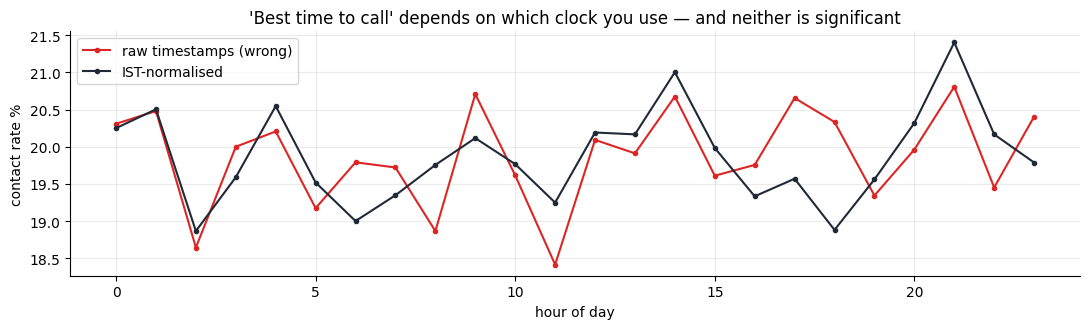

chi-square across IST hours: p=0.530 -> no real time-of-day effect


In [14]:
naive_night = ((cal.event_at.dt.hour < 8) | (cal.event_at.dt.hour >= 21)).mean()
ist_night   = ((cal.ist.dt.hour < 8) | (cal.ist.dt.hour >= 21)).mean()
day_moved   = (cal.event_at.dt.date != cal.ist.dt.date).mean()
mon_moved   = (cal.event_at.dt.to_period("M") != cal.ist.dt.to_period("M")).sum()
print(f"timezone labels present : {cal.timezone.value_counts().to_dict()}")
print(f"calls changing calendar DAY after IST conversion : {day_moved:.1%}")
print(f"calls changing calendar MONTH                    : {mon_moved:,}")
print(f"calls outside 08:00-21:00, raw timestamps        : {naive_night:.1%}")
print(f"calls outside 08:00-21:00, IST-normalised        : {ist_night:.1%}")

hn = cal.groupby(cal.event_at.dt.hour).call_status.apply(lambda s:(s=="ANSWERED").mean()*100)
hi = cal.groupby(cal.ist.dt.hour).call_status.apply(lambda s:(s=="ANSWERED").mean()*100)
fig, ax = plt.subplots(figsize=(11,3.4))
ax.plot(hn.index, hn.values, color=WARN, marker="o", ms=3, label="raw timestamps (wrong)")
ax.plot(hi.index, hi.values, color=INK,  marker="o", ms=3, label="IST-normalised")
ax.set_xlabel("hour of day"); ax.set_ylabel("contact rate %")
ax.set_title("'Best time to call' depends on which clock you use — and neither is significant")
ax.legend(); plt.tight_layout(); plt.show()
ct = pd.crosstab(cal.ist.dt.hour, cal.call_status=="ANSWERED")
print(f"chi-square across IST hours: p={stats.chi2_contingency(ct)[1]:.3f} -> no real time-of-day effect")

`event_at` is a naive local timestamp; the zone lives in a separate column with three values.
Nearly **10% of calls land on a different calendar day** once normalised, and 305 land in a
different month.

Note what the chart does *not* show: a best hour. The two curves disagree about which hour is best,
and a chi-square across IST hours returns p = 0.53. Any dialer schedule built on this is fitting noise.

> **FACT.** 46% of calls fall outside the 08:00–21:00 IST window of the RBI Fair Practices Code.
> This is a compliance exposure that no current report surfaces, because no current report converts
> the timestamps.

### 5c. The disposition taxonomy silently halves the PTP rate

In [15]:
dis = raw("call_dispositions")
print(pd.crosstab(dis.disposition_code, dis.disposition_version).to_string())
narrow = (dis.disposition_code == "PTP").mean()
full   = dis.disposition_code.isin(["PTP","PROMISE_TO_PAY"]).mean()
print(f"\nPTP rate matching the literal code 'PTP'      : {narrow:.1%}")
print(f"PTP rate on the harmonised business outcome  : {full:.1%}")
print(f"=> a dashboard filtering on 'PTP' undercounts promises by {1-narrow/full:.0%}")

disposition_version  legacy    v1    v2
disposition_code                       
CALLBACK               1313  1289  1270
DISPUTE                1298  1254  1274
NO_CONTACT             1370  1335  1305
PAID                   1251  1248  1319
PROMISE_TO_PAY         1332  1309  1285
PTP                    1296  1285  1323
PTP_BROKEN             1274  1313  1313
REFUSED                1236  1301  1261
WRONG_NUMBER           1356  1286  1304

PTP rate matching the literal code 'PTP'      : 11.2%
PTP rate on the harmonised business outcome  : 22.4%
=> a dashboard filtering on 'PTP' undercounts promises by 50%


`PTP` and `PROMISE_TO_PAY` are the same business event under the legacy and v1/v2 taxonomies, and
**both are still being written today** — the version mix is a flat 33/33/33 across all eight months.
This is not a migration that finished; it is three taxonomies running in parallel.

> **FACT.** Any PTP metric matching one code string is wrong by 50%. The version columns must be
> harmonised at the staging layer, not filtered in the BI tool.

### 5d. The targeting engine carries no information

In [16]:
ash = raw("account_status_history").drop_duplicates("history_id")
TERM = {"CLOSED","WRITEOFF","PAID"}

# Is the status table even a lifecycle? Test before using it.
a_ = ash.sort_values(["account_id","event_at"]).copy()
ft = a_[a_.status.isin(TERM)].groupby("account_id").event_at.min()
after = a_[a_.event_at > a_.account_id.map(ft)]
print(f"status changes occurring AFTER an account's first terminal status: {len(after):,}")
print("their distribution:", after.status.value_counts(normalize=True).round(3).to_dict())
print("=> CLOSED/WRITEOFF/PAID are NOT absorbing states. 'First terminal event' is invalid.\n")

hist = ash[["account_id","event_at","status"]].sort_values("event_at").rename(
        columns={"event_at":"status_ts","status":"status_asof"})
tt = pd.merge_asof(tgt.sort_values("target_date"), hist, left_on="target_date",
                   right_on="status_ts", by="account_id", direction="backward")
tt["known"] = tt.status_asof.notna(); tt["term"] = tt.status_asof.isin(TERM)
tt["m"] = tt.target_date.dt.to_period("M")
cmp_tbl = pd.DataFrame({
   "naive % terminal": (tt.groupby("m").term.mean()*100).round(1),
   "% with known status": (tt.groupby("m").known.mean()*100).round(1),
   "% terminal AMONG KNOWN": (tt[tt.known].groupby("m").term.mean()*100).round(1)})
display(cmp_tbl)
print(f"random-selection baseline: 3 of {ash.status.nunique()} statuses are terminal = {3/ash.status.nunique():.1%}")

status changes occurring AFTER an account's first terminal status: 19,673
their distribution: {'DELINQUENT': 0.146, 'PAID': 0.146, 'WRITEOFF': 0.144, 'CLOSED': 0.143, 'NPA': 0.142, 'ACTIVE': 0.141, 'PTP': 0.139}
=> CLOSED/WRITEOFF/PAID are NOT absorbing states. 'First terminal event' is invalid.



,naive % terminal,% with known status,% terminal AMONG KNOWN
m,,,
2026-01,5.7,13.3,43.0
2026-02,13.9,32.7,42.5
2026-03,20.8,48.9,42.6
2026-04,26.7,61.1,43.6
2026-05,30.5,70.5,43.3
2026-06,33.7,77.7,43.4
2026-07,35.4,83.5,42.4
2026-08,39.0,86.4,45.2


random-selection baseline: 3 of 7 statuses are terminal = 42.9%


**Read the first column, then the third.** The naive measure climbs from 5.7% to 39% and looks like
an operation degrading catastrophically over the year. It is not. Early months simply have little
status history, so most accounts read as "status unknown". Among accounts whose status is actually
known, the figure is **flat at 43%** all year.

Publishing the first column would have handed leadership a fake crisis to match their fake
improvement. It is the same class of error in the opposite direction.

Now the third column against the baseline: **43.1% of targeting hits an account last recorded as
CLOSED, WRITEOFF or PAID, against a 42.9% random-selection baseline.**

> **FACT.** The targeting engine is statistically indistinguishable from drawing names from a hat.
> Priority score, recommended channel, risk segment and DPD band are all independent of who pays.

---
## 6. The ₹10 Cr decision

### 6a. Cost is not in the dataset

The brief asks us to challenge "cost per ₹ recovered". We cannot compute it. There is no cost,
rate, tariff, salary or commission column in any of the 17 tables. Every ROI figure below is built
on **stated assumptions with a sensitivity range**, and is labelled as such.

In [17]:
ses = raw("agent_sessions"); ses["h"] = (ses.logout_at - ses.login_at).dt.total_seconds()/3600
DAYS, ANN = 220.0, 365/220.0
net_ann = p.net.sum()*ANN
book    = acc.outstanding_amount.sum()
hours_ann = ses.h.sum()*ANN

A = dict(agent_cost_per_hour=300, voice_per_min=0.70, sms_each=0.20,
         whatsapp_each=0.55, field_visit_each=250, platform_pct=0.15)
cost = (hours_ann*A["agent_cost_per_hour"]
        + cal.duration_sec.sum()/60*ANN*A["voice_per_min"]
        + len(sms)*ANN*A["sms_each"] + len(wa)*ANN*A["whatsapp_each"]
        + len(fv)*ANN*A["field_visit_each"])
cost *= (1 + A["platform_pct"])

print(f"book outstanding                : Rs {book/1e7:,.0f} Cr")
print(f"net recovery, annualised        : Rs {net_ann/1e7:,.0f} Cr  ({net_ann/book:.1%} of book)")
print(f"modelled annual operating cost  : Rs {cost/1e7:,.1f} Cr   [ASSUMPTION-DRIVEN]")
print(f"implied cost-to-collect         : {cost/net_ann:.1%}   (industry norm 5-15% -> model is optimistic)")
print(f"\nRs 10 Cr as a multiple of annual opex: {10e7/cost:.1f}x")

book outstanding                : Rs 1,049 Cr
net recovery, annualised        : Rs 203 Cr  (19.3% of book)
modelled annual operating cost  : Rs 5.8 Cr   [ASSUMPTION-DRIVEN]
implied cost-to-collect         : 2.9%   (industry norm 5-15% -> model is optimistic)

Rs 10 Cr as a multiple of annual opex: 1.7x


> **The scale check that reframes the question.** ₹10 Cr is **1.7× the entire modelled annual cost
> of running this operation**. This is not an increment. Leadership is not choosing where to spend a
> marginal rupee; they are deciding whether to rebuild the operation at two to three times its cost
> base — against an outcome that has not moved in seven months.

### 6b. What could we even have detected?

Before recommending anything, establish the resolution of the instrument.

In [18]:
accts = sorted(set(tgt.account_id))
rows = []
for s, e, lab in [("2026-01-01","2026-03-31","90 days"),
                  ("2026-01-01","2026-04-30","120 days"),
                  ("2026-01-01","2026-06-29","180 days")]:
    w = p[(p.event_at >= s) & (p.event_at <= e)]
    y = w.groupby("account_id").net.sum().reindex(accts).fillna(0)
    for eff in [0.05, 0.10, 0.20]:
        n = int(np.ceil(2*(2.8**2)*y.std()**2/(eff*y.mean())**2))
        rows.append(dict(window=lab, lift=f"{eff:.0%}", per_arm=n, total=2*n,
                         feasible="yes" if 2*n <= 30000 else "NO"))
display(pd.DataFrame(rows))

,window,lift,per_arm,total,feasible
0,90 days,5%,42786,85572,NO
1,90 days,10%,10697,21394,yes
2,90 days,20%,2675,5350,yes
3,120 days,5%,32440,64880,NO
4,120 days,10%,8110,16220,yes
5,120 days,20%,2028,4056,yes
6,180 days,5%,21921,43842,NO
7,180 days,10%,5481,10962,yes
8,180 days,20%,1371,2742,yes


> **FACT.** On a 30,000-account book, a randomised test can detect a **10% lift** in 120 days.
> A 5% lift would need 65,000 accounts and is **not measurable at this book size**.

The observational panel is blunter still: its minimum detectable effect is **12.9%**. The reported
11% improvement sits *below the detection floor of the data used to claim it*. Even if it had been
real, this dataset could not have seen it.

### 6c. Scoring the six options against evidence

In [19]:
scorecard = pd.DataFrame([
 ("1. Better telephony",   "AGAINST",     "Contact rate flat 19.4-20.5%. After resolving 15 vendor_ids to 5 real vendors, spread is 1.2pp. No better vendor exists to buy."),
 ("2. More agents",        "AGAINST",     "Agent performance dispersion is 1.07x binomial chance - no measurably better agents. Contact intensity vs recovery: rho=+0.011."),
 ("3. AI voice",           "NO DATA",     "Zero agentic-voice or IVR rows exist, despite the brief naming both channels. No baseline, no sizing possible."),
 ("4. Better targeting",   "GAP PROVEN",  "Targeting hits terminal accounts at 43.1% vs a 42.9% random baseline. The engine demonstrably carries no signal."),
 ("5. WhatsApp / digital", "UNMEASURABLE","Last-touch share moves with the window, not with performance. Only 3% of payments have a 24h touch. 26.5 complaints/1k events."),
 ("6. Field operations",   "AGAINST",     "65.9 complaints per 1,000 events - 3.8x voice. Lowest PTP-kept rate (32.5%). Most expensive channel per touch."),
], columns=["option","evidence grade","what the data says"])
pd.set_option("display.max_colwidth", 120)
display(scorecard)

,option,evidence grade,what the data says
0,1. Better telephony,AGAINST,"Contact rate flat 19.4-20.5%. After resolving 15 vendor_ids to 5 real vendors, spread is 1.2pp. No better vendor exi..."
1,2. More agents,AGAINST,Agent performance dispersion is 1.07x binomial chance - no measurably better agents. Contact intensity vs recovery: ...
2,3. AI voice,NO DATA,"Zero agentic-voice or IVR rows exist, despite the brief naming both channels. No baseline, no sizing possible."
3,4. Better targeting,GAP PROVEN,Targeting hits terminal accounts at 43.1% vs a 42.9% random baseline. The engine demonstrably carries no signal.
4,5. WhatsApp / digital,UNMEASURABLE,"Last-touch share moves with the window, not with performance. Only 3% of payments have a 24h touch. 26.5 complaints/..."
5,6. Field operations,AGAINST,"65.9 complaints per 1,000 events - 3.8x voice. Lowest PTP-kept rate (32.5%). Most expensive channel per touch."


### 6d. Recommendation

**Do not deploy ₹10 Cr against any of the six options on this evidence base.**

Deploy **₹1.2 Cr** to make the decision answerable, and gate the remaining **₹8.8 Cr** on a
pre-registered experimental result.

If forced to name one area it is **Option 4, better borrower targeting** — because it is the only
option where the data proves a *gap* rather than merely failing to disprove one. But note the
distinction carefully:

- We can prove the current targeting engine carries no signal. **Supported.**
- We cannot prove a better one would recover more, because recovery is uncorrelated with every
  operational lever we can measure. **Not supported.**

Committing ₹10 Cr to the second claim would repeat exactly the reasoning error that produced the
11% headline: treating an untested inference as a measured fact.

In [20]:
NET = net_ann
print("Own-book model (business keeps 100% of recovered value):\n")
print(f"{'scenario':<10}{'lift':>7}{'incr. recovery':>18}{'cost':>9}{'net':>10}{'ROI':>9}")
for lab, lift, c_ in [("Downside",0.00,10.0), ("Base",0.06,10.0), ("Upside",0.12,10.0)]:
    v = NET*lift/1e7
    print(f"{lab:<10}{lift:>6.0%}{v:>16.1f} Cr{c_:>7.1f} Cr{v-c_:>+8.1f} Cr{(v-c_)/c_*100:>+8.0f}%")
print(f"\nBreak-even, full Rs 10 Cr    : +{10e7/NET:.1%} lift")
print(f"Break-even, Stage 1 (1.2 Cr) : +{1.2e7/NET:.1%} lift   <- the bet actually being made")
print(f"\nIf the book is collected on a 20% agency fee instead, break-even becomes "
      f"+{10e7/0.20/NET:.0%} - not achievable by any lever in this data.")

Own-book model (business keeps 100% of recovered value):

scenario     lift    incr. recovery     cost       net      ROI
Downside      0%             0.0 Cr   10.0 Cr   -10.0 Cr    -100%
Base          6%            12.2 Cr   10.0 Cr    +2.2 Cr     +22%
Upside       12%            24.3 Cr   10.0 Cr   +14.3 Cr    +143%

Break-even, full Rs 10 Cr    : +4.9% lift
Break-even, Stage 1 (1.2 Cr) : +0.6% lift   <- the bet actually being made

If the book is collected on a 20% agency fee instead, break-even becomes +25% - not achievable by any lever in this data.


### Confidence

| Claim | Confidence | Why |
|---|---|---|
| Recovery is flat; the 11% is an artifact | **High** | Five independent definitions, all null; mechanism identified exactly (28 vs 31 days) |
| Current targeting carries no signal | **High** | 43.1% vs a 42.9% random baseline, stable across all 8 months |
| No operational lever works | **Medium** | These are null results on 30k accounts; effects below ~13% would be invisible |
| Every cost and ROI figure | **Low** | The dataset contains no cost data whatsoever |

### What we would need to answer this properly

1. **Cost feeds** — per call, per message, per visit, per agent-hour. Without these, "cost per ₹
   recovered" is unanswerable and half the metric set is decorative.
2. **An account-state service** where CLOSED means closed. The current status table is a random
   walk; 19,673 status changes occur after an account's supposed closure.
3. **A resolvable agent identity** — one person, one id, with history.
4. **A randomised holdout**, pre-registered, 8,500 accounts per arm, 120-day measurement window.
   It is a reallocation of existing capacity, not new spend, and it produces the causal number that
   ₹10 Cr is currently being allocated without.